In [1]:
from api import profiling
import matplotlib.pyplot as plt

# Shared GPU: other jobs' memory caps the reachable num_envs and their compute load lowers fps, so record who else
# is on the GPU alongside the results.
print(profiling.gpu_status())

name, memory.used [MiB], memory.total [MiB], utilization.gpu [%]
NVIDIA GeForce RTX 5090, 28506 MiB, 32607 MiB, 2 %
pid, used_gpu_memory [MiB], process_name
317437, 26889 MiB, /home/somatic/zach/blind_box_pick/play2perceive/.venv_isaacsim/bin/python
1443992, 951 MiB, /home/somatic/faraz/control-proj/control/.venv/bin/python


In [2]:
# Frames/s = num_envs * env steps / wall-clock s, GPU sim (physx_cuda), random actions pre-generated on the GPU,
# observations left on the GPU. 20 warmup + 200 timed steps per point; each point runs in its own subprocess
# (see api/profiling.py). For each (mode, resolution), num_envs doubles until the first failure (typically the
# GPU running out of memory for the camera buffers) -- larger counts would fail too.
#   state: physics only | rgb: + render base_camera RGB | track: + rgb/position/segmentation + 32x32 GT grid tracking
TASK = "StackCube-v1"
NUM_ENVS = [1, 4, 16, 64, 256, 1024, 2048, 4096, 8192, 16384]
CONFIGS = [("state", None), ("rgb", 128), ("rgb", 512), ("track", 128), ("track", 512)]

rows = []
for mode, res in CONFIGS:
    for n in NUM_ENVS:
        r = profiling.run(task=TASK, mode=mode, num_envs=n, **({"resolution": res} if res else {}))
        r["config"] = mode if res is None else f"{mode} @ {res}px"
        rows.append(r)
        print(f"{r['config']:14s} num_envs={n:6d}  " + (f"{r['fps']:10.0f} fps  ({r['ms_per_step']:.1f} ms/step, "
              f"{r['gpu_mem_gb']:.1f} GB)" if "error" not in r else f"FAILED: {r['error'][:90]}"))
        if "error" in r:
            break
ok = [r for r in rows if "error" not in r]

state          num_envs=     1          56 fps  (17.9 ms/step, 1.7 GB)


state          num_envs=     4         211 fps  (18.9 ms/step, 1.7 GB)


state          num_envs=    16         700 fps  (22.9 ms/step, 1.7 GB)


state          num_envs=    64        2197 fps  (29.1 ms/step, 1.7 GB)


state          num_envs=   256        7225 fps  (35.4 ms/step, 1.8 GB)


...

track @ 512px  num_envs=     1          48 fps  (20.9 ms/step, 1.9 GB)


track @ 512px  num_envs=     4         168 fps  (23.9 ms/step, 2.0 GB)


track @ 512px  num_envs=    16         589 fps  (27.2 ms/step, 2.1 GB)


track @ 512px  num_envs=    64        1800 fps  (35.6 ms/step, 2.9 GB)


track @ 512px  num_envs=   256  FAILED: RuntimeError: Unable to create GPU parallelized camera group. If the error is about being 


In [3]:
# Peak throughput per setting ("maximally parallelized" = best num_envs that fit alongside whatever else is on the GPU)
configs = list(dict.fromkeys(r["config"] for r in ok))
print(f"{'setting':14s} {'num_envs':>8s} {'frames/s':>10s} {'ms/step':>8s} {'GPU GB':>7s}")
for config in configs:
    b = max((r for r in ok if r["config"] == config), key=lambda r: r["fps"])
    print(f"{config:14s} {b['num_envs']:8d} {b['fps']:10,.0f} {b['ms_per_step']:8.1f} {b['gpu_mem_gb']:7.1f}")

setting        num_envs   frames/s  ms/step  GPU GB
state              4096     60,272     68.0     3.0
rgb @ 128px        1024     12,664     80.9     3.3
rgb @ 512px          64      1,854     34.5     2.6
track @ 128px        64      1,753     36.5     2.0
track @ 512px        64      1,800     35.6     2.9


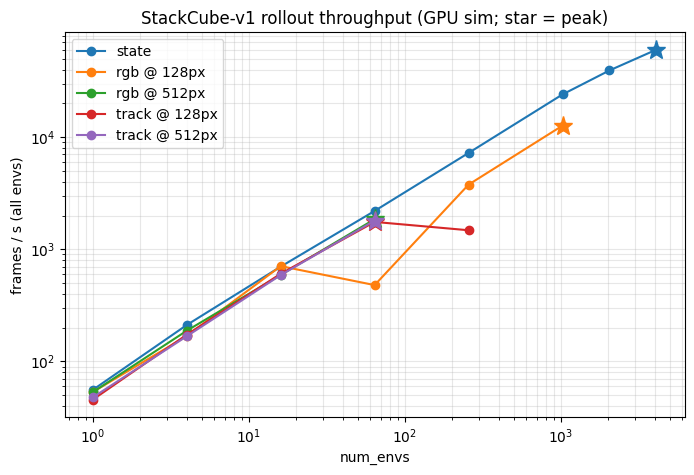

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for config in configs:
    g = [r for r in ok if r["config"] == config]
    line, = ax.plot([r["num_envs"] for r in g], [r["fps"] for r in g], "o-", label=config)
    best = max(g, key=lambda r: r["fps"])
    ax.plot(best["num_envs"], best["fps"], "*", ms=14, color=line.get_color())
ax.set(xscale="log", yscale="log", xlabel="num_envs", ylabel="frames / s (all envs)",
       title=f"{TASK} rollout throughput (GPU sim; star = peak)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

In [5]:
# Cost of the tracking itself vs. stepping + rendering, per tracked step (each part synced separately).
print(f"{'setting':14s} {'num_envs':>8s} {'step+render ms':>15s} {'locate ms':>10s} {'locate share':>13s}")
for r in ok:
    if r["mode"] == "track":
        share = r["ms_locate"] / (r["ms_step_render"] + r["ms_locate"])
        print(f"{r['config']:14s} {r['num_envs']:8d} {r['ms_step_render']:15.1f} {r['ms_locate']:10.2f} {share:13.1%}")

setting        num_envs  step+render ms  locate ms  locate share
track @ 128px         1            20.5       2.05          9.1%
track @ 128px         4            20.4       2.47         10.8%
track @ 128px        16            23.9       2.60          9.8%
track @ 128px        64            31.9       2.64          7.6%
track @ 128px       256           162.3       3.64          2.2%
track @ 512px         1            19.3       1.91          9.0%
track @ 512px         4            22.1       2.37          9.7%
track @ 512px        16            27.0       2.38          8.1%
track @ 512px        64            36.5       2.44          6.3%
